In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import asyncio
#from rtlsdr import RtlSdr
#import ugradio
from scipy.ndimage import median_filter, uniform_filter1d

In [30]:
data_sg = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/bighorn_signal_test.npz")
data_scal = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_blackbody_0302 (1).npz")
data_scold = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_zenith_0302.npz")
data_son = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/cygnus x new/bighorn_cyg_x_on.npz") 
data_soff = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/cygnus x new/bighorn_cyg_x_off_2MHz.npz")

bits_to_volts = 1 #8.11968986e-06
antenna_efficiency = 0.65 #placeholder for now
print("bits to volts at 45dB gain: 8.11968986e-06 +- 3.02632578e-06 V/Bit")

bits to volts at 45dB gain: 8.11968986e-06 +- 3.02632578e-06 V/Bit


In [31]:
print(data_son.files)

['samples', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_nch', 'center_freq', 'sample_rate']


In [32]:
def power_spectrum_average(data, method='mean'):
    """
    Calculates the averaged power spectrum of multiple complex I/Q signals.
    
    Parameters:
    samples (np.ndarray): A 3D array of shape (M, N, 2) 
                      where M = number of observations, N = samples per observation.
    fs (float): The sampling rate in Hz.
    method (str): 'mean' or 'median' to combine the spectra.
    
    Returns:
    freqs_shifted (np.ndarray): The centered frequency axis.
    averaged_power (np.ndarray): The averaged power spectrum of size N.
    """
    # Get the number of observations (M) and samples per observation (N)
    M, N, _ = data["samples"].shape
    
    # 1. Convert the (M, N, 2) array into a 2D complex array of shape (M, N)
    # samples[:, :, 0] is the Real (I) and samples[:, :, 1] is the Imaginary (Q)
    complex_signal = (data["samples"][:, :, 0] * bits_to_volts / antenna_efficiency) + 1j * (data["samples"][:, :, 1] * bits_to_volts / antenna_efficiency)
    
    # 2. Compute the FFT along the N dimension (axis=1) for all M arrays simultaneously
    fft_result = np.fft.fft(complex_signal, axis=1)
    
    # 3. Shift the zero-frequency (DC) component to the center of the array
    fft_shifted = np.fft.fftshift(fft_result, axes=1)
    
    # 4. Calculate the power spectrum for all M arrays
    power = np.abs(fft_shifted)**2 / N
    
    # 5. Average the power spectra across the M observations (axis=0)
    if method == 'median':
        averaged_power = np.median(power, axis=0)
    else:
        averaged_power = np.mean(power, axis=0)
        
    # 6. Generate the frequency axis and shift it
    freqs = np.fft.fftfreq(N, d=1/data["sample_rate"]) + data["center_freq"]
    freqs_shifted = np.fft.fftshift(freqs)
    
    return freqs_shifted, averaged_power

def robust_clean_and_smooth(power_spectrum, window_size=31, threshold_sigma=3.0, smooth_channels=5):
    """
    Cleans RFI spikes using a rolling Median Absolute Deviation (MAD) and smoothes the result.
    This safely preserves broad physical signals (like the HI bump) while removing narrow spikes.
    
    Parameters:
    power_spectrum (np.ndarray): 1D array of the power spectrum.
    window_size (int): Must be wider than the RFI spike, but narrower than the HI bump.
    threshold_sigma (float): Number of standard deviations to trigger outlier detection.
    smooth_channels (int): Window size for the final moving average smoothing.
    """
    
    # 1. Calculate the rolling median
    # This creates a baseline that tracks the HI bump but cuts straight through the narrow spike
    rolling_median = median_filter(power_spectrum, size=window_size)
    
    # 2. Calculate the local noise floor using Median Absolute Deviation (MAD)
    # MAD is highly resistant to outliers compared to standard deviation
    abs_diff = np.abs(power_spectrum - rolling_median)
    rolling_mad = median_filter(abs_diff, size=window_size)
    
    # Scale MAD to an equivalent standard deviation for a normal distribution
    rolling_std = rolling_mad * 1.4826
    
    # 3. Create a mask of outliers
    # We add a tiny epsilon to avoid division by zero in perfectly flat regions
    epsilon = 1e-10
    outlier_mask = abs_diff > (threshold_sigma * rolling_std + epsilon)
    
    # 4. Replace the bad spikes with the safe rolling median
    cleaned_power = np.copy(power_spectrum)
    cleaned_power[outlier_mask] = rolling_median[outlier_mask]
    
    # 5. Smooth the cleaned data
    smoothed_power = uniform_filter1d(cleaned_power, size=smooth_channels)
    
    return smoothed_power, outlier_mask, rolling_median

def find_hi_peak(freqs, cleaned_spectrum):
    """
    Identifies the maximum value of the smoothed HI line and returns its frequency.
    
    Parameters:
    freqs (np.ndarray): 1D array of the frequency axis.
    cleaned_spectrum (np.ndarray): 1D array of the smoothed power spectrum (or baseline).
    
    Returns:
    peak_freq (float): The frequency where the HI line peaks.
    peak_power (float): The power magnitude at the peak.
    peak_idx (int): The array index of the peak.
    """
    # Find the index of the absolute maximum value in the spectrum
    peak_idx = np.argmax(cleaned_spectrum)
    
    # Extract the corresponding frequency and power using that index
    peak_freq = freqs[peak_idx]
    peak_power = cleaned_spectrum[peak_idx]
    
    return peak_freq, peak_power, peak_idx

In [33]:
freq_son, power_son = power_spectrum_average(data_son, method = "median")
freq_soff, power_soff = power_spectrum_average(data_soff, method = "median") # change to data_soff
freq_scal, power_scal = power_spectrum_average(data_scal, method = "median") # change to data_soff
freq_scold, power_scold = power_spectrum_average(data_scold, method = "median") # change to data_soff

power_son_smoothed, outliers_son, rolling_son = robust_clean_and_smooth(power_son)
power_soff_smoothed, outliers_soff, rolling_soff = robust_clean_and_smooth(power_soff)
power_scal_smoothed, outliers_scal, rolling_scal = robust_clean_and_smooth(power_scal)
power_scold_smoothed, outliers_scold, rolling_scold = robust_clean_and_smooth(power_scold)

r = power_son / power_soff
r_smooth = power_son_smoothed / power_soff_smoothed
r_rolling = rolling_son / rolling_soff

freq_peak, power_peak, idx_peak = find_hi_peak(freq_son, r_rolling)

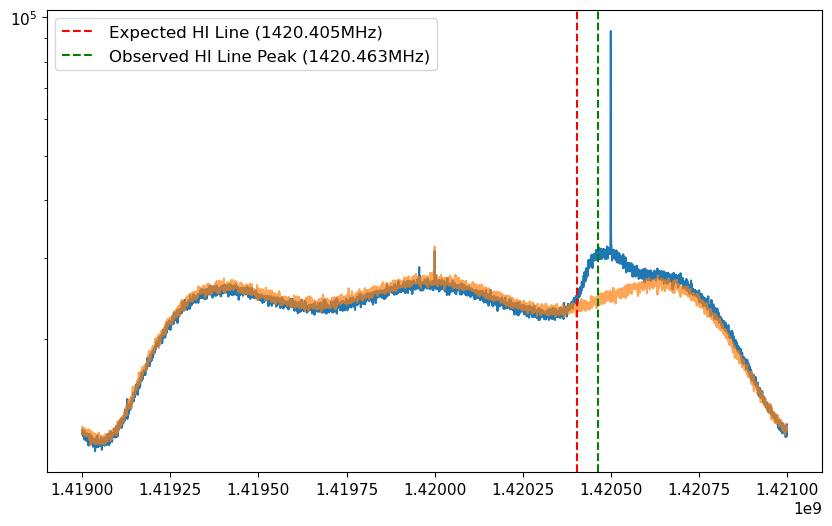

In [34]:
plt.figure(figsize = (10, 6))

plt.plot(freq_son, power_son)
plt.plot(freq_soff, power_soff, alpha = 0.7)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.7}MHz)")
plt.legend()
plt.yscale("log")

In [35]:
print(data_scal["samples"], data_scold["samples"])

[[[  -1    0]
  [  -1   -1]
  [   0   -1]
  ...
  [-128   46]
  [  42  127]
  [  24  -97]]

 [[  39   25]
  [ 127  -92]
  [-128 -114]
  ...
  [   2  122]
  [ -60  127]
  [  64  -34]]

 [[-115  103]
  [ -52  120]
  [  39  -60]
  ...
  [ 127  108]
  [  56 -128]
  [-111   51]]

 ...

 [[-128  -37]
  [ -61 -128]
  [ 127  -44]
  ...
  [-128 -128]
  [  72  -48]
  [ 127   31]]

 [[  36  100]
  [ -52  -97]
  [  91   69]
  ...
  [   6  -40]
  [  91  -69]
  [ -20  127]]

 [[  -4   98]
  [ 127  127]
  [-128    5]
  ...
  [ -94   90]
  [  66  -37]
  [ 110  -43]]] [[[ -20   20]
  [ -19   26]
  [  -1  -34]
  ...
  [ -94 -128]
  [ 127   -9]
  [  54  127]]

 [[  -1 -119]
  [ -65   97]
  [ 127  -32]
  ...
  [ -90  -45]
  [ -69  120]
  [ -49   92]]

 [[  34  -15]
  [ -60   70]
  [  20 -106]
  ...
  [   5  -56]
  [  18 -122]
  [ 101  121]]

 ...

 [[ -90 -119]
  [  76 -120]
  [-105   22]
  ...
  [ -68 -111]
  [  13   96]
  [ -13  -49]]

 [[ -20  127]
  [  39  -34]
  [ 127  -21]
  ...
  [  55 -128]
  [ -9

[False False False ... False False False]


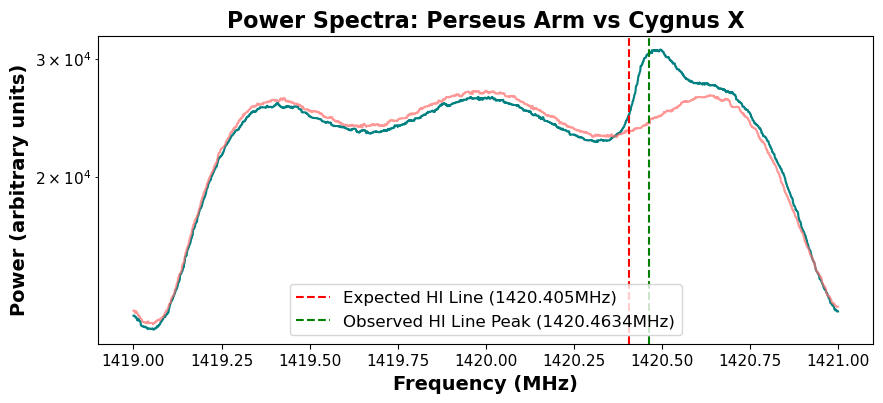

In [36]:
print(outliers_son)
plt.figure(figsize = (10, 4))
plt.plot(freq_son/1e6, rolling_son, color = "#008080")
plt.plot(freq_soff/1e6, rolling_soff, color = "#FF6B6B", alpha = 0.7)
plt.axvline(1420.405e6/1e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak/1e6, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.yscale("log")
plt.xlabel('Frequency (MHz)', fontsize=14, fontweight='bold')
plt.ylabel('Power (arbitrary units)', fontsize=14, fontweight='bold')
plt.title('Power Spectra: Perseus Arm vs Cygnus X', fontsize=16, fontweight='bold')
plt.legend()
plt.savefig('fig2_power_spectra.pdf', bbox_inches='tight')
plt.show()

[False False False ... False False False]


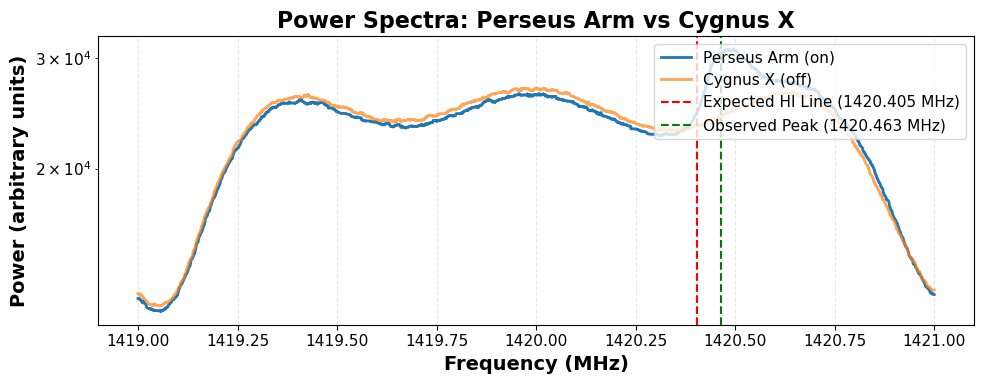

In [37]:
print(outliers_son)
plt.figure(figsize=(10, 4))

# Add colors and linewidth
plt.plot(freq_son/1e6, rolling_son, color='#1f77b4', linewidth=2, label='Perseus Arm (on)')
plt.plot(freq_soff/1e6, rolling_soff, color='#ff7f0e', linewidth=2, alpha=0.7, label='Cygnus X (off)')

# Vertical lines
plt.axvline(1420.405, color="red", linestyle="--", linewidth=1.5, label="Expected HI Line (1420.405 MHz)")
plt.axvline(freq_peak/1e6, color="green", linestyle="--", linewidth=1.5, 
            label=f"Observed Peak ({freq_peak/1e6:.3f} MHz)")

plt.yscale("log")
plt.xlabel('Frequency (MHz)', fontsize=14, fontweight='bold')
plt.ylabel('Power (arbitrary units)', fontsize=14, fontweight='bold')
plt.title('Power Spectra: Perseus Arm vs Cygnus X', fontsize=16, fontweight='bold')

# Add grid and improve y-axis ticks
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right')

# Clean up y-axis ticks (optional - remove if you like the defaults)
plt.tick_params(axis='both', which='major', labelsize=11)

# Optional: Set y-axis limits if needed
# plt.ylim(1e3, 1e5)

plt.tight_layout()
plt.show()

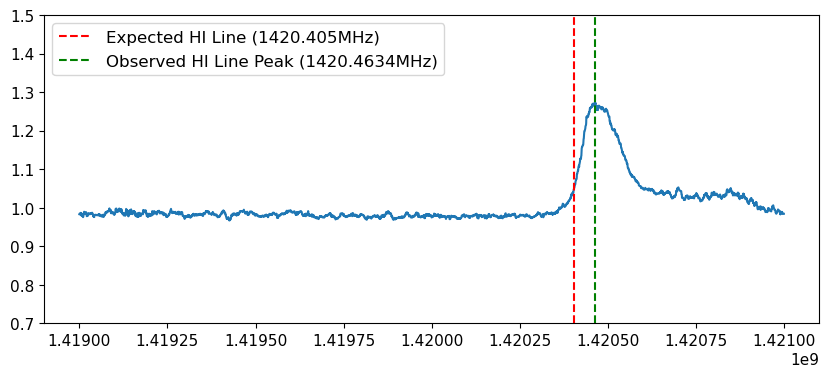

In [38]:
r = power_son / power_soff
r_smooth = power_son_smoothed / power_soff_smoothed
r_rolling = rolling_son / rolling_soff

plt.figure(figsize=(10, 4))
# plt.plot(freq_son, r)
# plt.plot(freq_son, r_smooth)
plt.plot(freq_son, r_rolling)
plt.ylim(0.7, 1.5)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.legend()
plt.show()

In [39]:
def gain(s_cal, s_cold, T_rx = 300, T_hot = 300, T_cold = 10):
    T_sys_cal = T_rx + T_hot
    T_sys_cold = T_rx + T_cold

    sum_cal = sum(s_cal)
    sum_diff = sum(s_cal - s_cold)

    G = ((T_sys_cal - T_sys_cold) * sum_cal) / sum_diff
    return 10 * np.log10(G)

G = gain(power_scal, power_scold)

T_son = r_rolling * G

print(G)

42.130844633509824


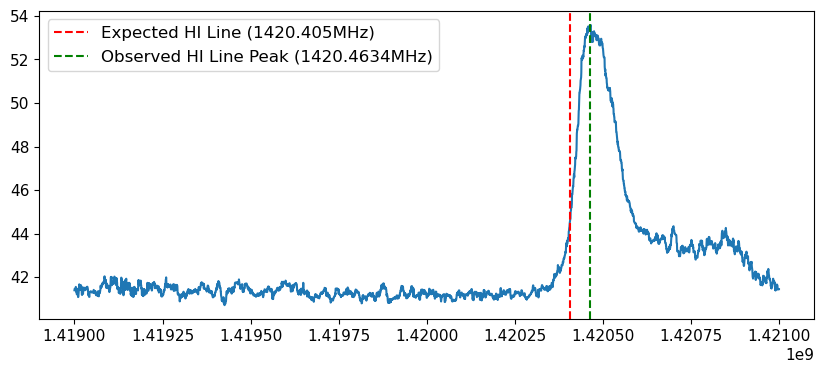

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(freq_son, T_son)
# plt.ylim(0.7, 1.5)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.legend()
plt.show()

In [41]:
def velocity(nu, nu_0=1420.406e6):
    delta_nu = nu - nu_0
    c = 299792458
    v = - (c * delta_nu) / nu
    return v

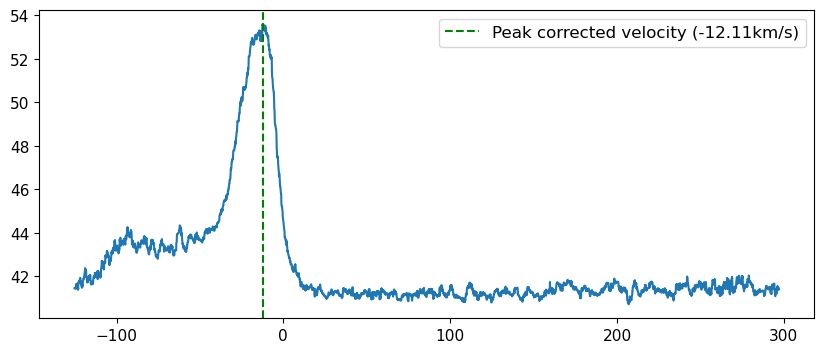

In [42]:
velocity_profile = velocity(freq_son)

v_peak, v_max, v_idx = find_hi_peak(velocity_profile, T_son)

plt.figure(figsize = (10, 4))
plt.plot(velocity_profile / 1000, T_son)
plt.axvline(v_peak / 1000, color = "green", linestyle = "--", label=f"Peak corrected velocity ({v_peak/1000:.6}km/s)")
plt.legend()

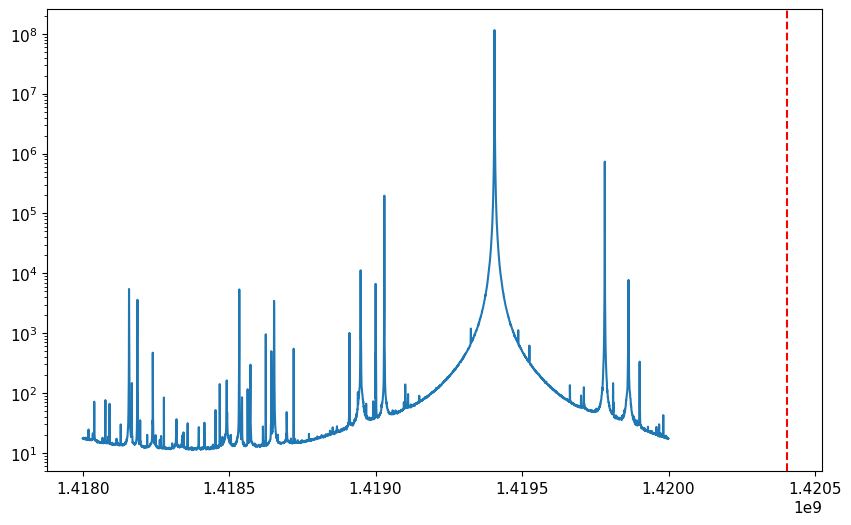

In [43]:
sg_freq, sg_power = power_spectrum_average(data_sg, method='mean')

plt.figure(figsize = (10, 6))

plt.axvline(1420.405e6, color = "red", linestyle = "--")
plt.semilogy(sg_freq, sg_power)

# Reference Frame

In [44]:
print(data_son.files)

['samples', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_nch', 'center_freq', 'sample_rate']


In [45]:
print(data_son["coords_nch"])

[  37.8732 -237.7427]


In [46]:
def get_rotation_matrices(data):
    """
    Generates a dictionary of 3x3 rotation matrices for coordinate transformations.
    
    Parameters:
    lat_deg (float): Observer's terrestrial latitude in degrees.
    lst_hours (float): Local Sidereal Time in decimal hours.
    
    Returns:
    dict: A dictionary containing the 6 requested rotation matrices.
    """

    lat_deg = data["coords_nch"][0]
    lst_hours = data["lst_before"]
    # Convert inputs to radians
    phi = np.radians(lat_deg)
    lst_rad = np.radians(lst_hours * 15.0)
    
    # ==========================================
    # 1. Define the base forward matrices
    # ==========================================
    
    # R_(ha, dec) -> (az, alt)
    R_ha_to_az = np.array([
        [-np.sin(phi), 0, np.cos(phi)],
        [0, -1, 0],
        [np.cos(phi), 0, np.sin(phi)]
    ])
    
    # R_(ra, dec) -> (ha, dec)
    R_ra_to_ha = np.array([
        [np.cos(lst_rad), np.sin(lst_rad), 0],
        [np.sin(lst_rad), -np.cos(lst_rad), 0],
        [0, 0, 1]
    ])
    
    # R_(ra, dec) -> (l, b)
    # Standard constant rotation matrix for J2000 Equatorial to Galactic
    R_ra_to_lb = np.array([
        [-0.05487556, -0.87343709, -0.48383502],
        [ 0.49410943, -0.44482963,  0.74698225],
        [-0.86766615, -0.19807637,  0.45598378]
    ])

    # ==========================================
    # 2. Calculate Inverses (Transposes)
    # ==========================================
    R_az_to_ha = np.linalg.inv(R_ha_to_az)
    R_ha_to_ra = np.linalg.inv(R_ra_to_ha)
    R_lb_to_ra = np.linalg.inv(R_ra_to_lb)
    
    # ==========================================
    # 3. Calculate Composite Matrices
    # ==========================================
    # (az, alt) -> (ra, dec) involves going from az->ha, then ha->ra.
    # In matrix math, the first operation goes on the right: R_final = R2 * R1
    R_az_to_ra = np.dot(R_ha_to_ra, R_az_to_ha)
    
    # The inverse is simply the transpose of the composite matrix
    R_ra_to_az = np.linalg.inv(R_az_to_ra)

    # ==========================================
    # 4. Build and return the dictionary
    # ==========================================
    matrices = {
        "az_alt_to_ra_dec": R_az_to_ra,
        "ra_dec_to_az_alt": R_ra_to_az,
        
        "ra_dec_to_ha_dec": R_ra_to_ha,
        "ha_dec_to_ra_dec": R_ha_to_ra,
        
        "l_b_to_ra_dec": R_lb_to_ra,
        "ra_dec_to_l_b": R_ra_to_lb
    }
    
    return matrices

def spherical_to_vector(longitude_rad, latitude_rad):
    """Converts spherical angles (in radians) to a 3D rectangular vector."""
    return np.array([
        np.cos(latitude_rad) * np.cos(longitude_rad), # x0
        np.cos(latitude_rad) * np.sin(longitude_rad), # x1
        np.sin(latitude_rad)                          # x2
    ])

def vector_to_spherical(v):
    """Converts a 3D rectangular vector back to spherical angles (in radians)."""
    longitude_rad = np.arctan2(v[1], v[0])
    latitude_rad = np.arcsin(v[2])
    return longitude_rad, latitude_rad

def az_alt_to_ra_dec(az_deg, alt_deg, rotations_dict):
    """
    Converts Azimuth/Altitude to RA/Dec using a provided dictionary of rotation matrices.
    """
    # Convert inputs to radians
    az_rad = np.radians(az_deg)
    alt_rad = np.radians(alt_deg)
    
    # 1. Convert to 3D vector (Azimuth is longitude, Altitude is latitude)
    x_az_alt = spherical_to_vector(az_rad, alt_rad)
    
    # 2. Grab the specific matrix and apply the rotation
    R = rotations_dict["az_alt_to_ra_dec"]
    x_ra_dec = np.dot(R, x_az_alt)
    
    # 3. Convert back to spherical angles
    ra_rad, dec_rad = vector_to_spherical(x_ra_dec)
    
    # Convert to degrees and wrap Right Ascension to 0-360
    ra_deg = np.degrees(ra_rad) % 360.0
    dec_deg = np.degrees(dec_rad)
    
    return ra_deg, dec_deg

def ra_dec_to_az_alt(ra_deg, dec_deg, rotations_dict):
    """
    Converts RA/Dec to Azimuth/Altitude using a provided dictionary of rotation matrices.
    """
    # Convert inputs to radians
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    
    # 1. Convert to 3D vector (Right Ascension is longitude, Declination is latitude)
    x_ra_dec = spherical_to_vector(ra_rad, dec_rad)
    
    # 2. Grab the specific inverse matrix and apply the rotation
    R = rotations_dict["ra_dec_to_az_alt"]
    x_az_alt = np.dot(R, x_ra_dec)
    
    # 3. Convert back to spherical angles
    az_rad, alt_rad = vector_to_spherical(x_az_alt)
    
    # Convert to degrees and wrap Azimuth to 0-360
    az_deg = np.degrees(az_rad) % 360.0
    alt_deg = np.degrees(alt_rad)
    
    return az_deg, alt_deg

# ==========================================
# 2. Convert (l, b) to (Alt, Az)
# ==========================================
def l_b_to_az_alt(l_deg, b_deg, rotations_dict):
    """
    Converts Galactic (l, b) to Azimuth/Altitude by chaining two rotation matrices.
    """
    # Convert inputs to radians
    l_rad = np.radians(l_deg)
    b_rad = np.radians(b_deg)
    
    # 1. Convert to 3D vector (l is longitude, b is latitude)
    x_l_b = spherical_to_vector(l_rad, b_rad)
    
    # 2. Chain the matrices to go (l, b) -> (RA, Dec) -> (Alt, Az)
    # Note: R_ra_dec_to_az_alt goes on the left because it operates LAST.
    R_lb_to_ra = rotations_dict["l_b_to_ra_dec"]
    R_ra_to_az = rotations_dict["ra_dec_to_az_alt"]
    
    R_full = np.dot(R_ra_to_az, R_lb_to_ra)
    
    # 3. Apply the combined rotation matrix
    x_az_alt = np.dot(R_full, x_l_b)
    
    # 4. Convert back to spherical angles
    az_rad, alt_rad = vector_to_spherical(x_az_alt)
    
    # Convert to degrees and wrap Azimuth to 0-360
    az_deg = np.degrees(az_rad) % 360.0
    alt_deg = np.degrees(alt_rad)
    
    return az_deg, alt_deg

In [47]:
# ==========================================
# Wrapper: Calculate using ugradio.timing
# ==========================================
def get_current_alt_az(target_lon, target_lat, coord_type="ra_dec"):
    """
    Takes a target coordinate and rotates it to the current Alt/Az for the observer
    using the ugradio.timing module.
    
    Parameters:
    target_lon : RA (if ra_dec) or l (if l_b) in degrees
    target_lat : Dec (if ra_dec) or b (if l_b) in degrees
    coord_type : "ra_dec" or "l_b"
    """
    
    # 1. Get current LST in radians from ugradio (uses current Unix time & nch.lon)
    lst_rad = ugradio.timing.lst()
    
    # 2. Convert LST from radians to decimal hours 
    # (Because get_rotation_matrices expects lst_hours)
    lst_hours = lst_rad * (12.0 / np.pi)
    
    # Grab the observatory latitude directly from ugradio
    lat_obs = ugradio.nch.lat
    
    # 3. Package into the format your get_rotation_matrices function expects
    data = {
        "coords_nch": [lat_obs], 
        "lst_before": lst_hours 
    }
    
    # 4. Generate the rotation matrices
    rotations_dict = get_rotation_matrices(data)
    
    # 5. Route to the correct calculation (assuming your previous functions are loaded)
    if coord_type == "ra_dec":
        az, alt = ra_dec_to_az_alt(target_lon, target_lat, rotations_dict)
    elif coord_type == "l_b":
        az, alt = l_b_to_az_alt(target_lon, target_lat, rotations_dict)
    else:
        raise ValueError("coord_type must be 'ra_dec' or 'l_b'")
        
    return az, alt, lst_hours

### system calibration

In [48]:
def calculate_system_temperature(p_hot, p_cold, t_hot=300.0, t_cold=10):
    """
    Calculates the Y-factor, receiver temperature, and system temperature.
    
    Parameters:
    p_hot (np.ndarray): The averaged power spectrum array for the hot load (e.g., ground).
    p_cold (np.ndarray): The averaged power spectrum array for the cold load (e.g., empty sky).
    t_hot (float): Physical temperature of the hot load in Kelvin (default ~290 K for ground).
    t_cold (float): Physical temperature of the cold empty sky in Kelvin (default ~15 K).
    
    Returns:
    t_sys (float): The system temperature in Kelvin.
    t_rx (float): The receiver noise temperature in Kelvin.
    y_factor (float): The calculated Y-factor ratio.
    """
    # 1. Extract a single baseline power scalar from the arrays using the median
    p_hot_scalar = np.median(p_hot)
    p_cold_scalar = np.median(p_cold)
    
    # 2. Calculate the Y-factor (ratio of hot to cold power)
    y_factor = p_hot_scalar / p_cold_scalar
    
    # Check to ensure Y-factor is valid (must be > 1)
    if y_factor <= 1.0:
        print("Warning: Y-factor is <= 1. Check your hot/cold measurements.")
        return None, None, y_factor
    
    # 3. Calculate the receiver's internal noise temperature (Trx)
    t_rx = (t_hot - y_factor * t_cold) / (y_factor - 1.0)
    
    # 4. Calculate the baseline System Temperature (Tsys)
    t_sys = t_rx + t_cold
    

    return t_sys, t_rx, y_factor

In [49]:
freq_hot, power_hot = power_spectrum_average(data_scal, method = "median")
freq_cold, power_cold = power_spectrum_average(data_scold, method = "median")

t_sys, t_rx, y_factor = calculate_system_temperature(power_hot, power_cold)

print(t_sys, t_rx, y_factor)

19739.632846203196 19729.632846203196 1.0146912560258576


### end-to-end calibration

#### homebrew amplifiers

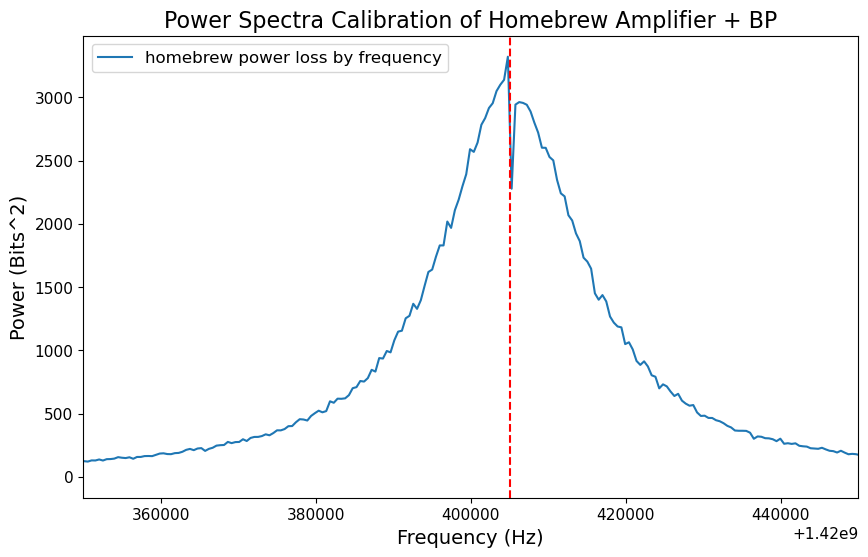

In [50]:
data_homebrew_on = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-1 Data/bighorn_homebrew_on.npz")
data_homebrew_off = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-1 Data/bighorn_homebrew_off.npz")

freqs_h_on, power_h_on = power_spectrum_average(data_homebrew_on)
freqs_h_off, power_h_off = power_spectrum_average(data_homebrew_off)

plt.figure(figsize = (10, 6))
# plt.plot(freqs_h_on, power_h_on, color="red", label = "homebrew amps on", alpha=0.7)
# plt.plot(freqs_h_off, power_h_off, label = "homebrew amps off", alpha=0.7)
# plt.yscale("log")
plt.xlim(1.42035e9, 1.42045e9)

r_h = power_h_off/power_h_on

plt.plot(freqs_h_on, r_h, label = "homebrew power loss by frequency")
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Bits^2)")
plt.title("Power Spectra Calibration of Homebrew Amplifier + BP")
# print(10*np.log(max(power_h_on)), 10*np.log(max(power_h_off)), 10*np.log(max(r_h)))
plt.axvline(1420.405e6, color = "red", linestyle = "--")

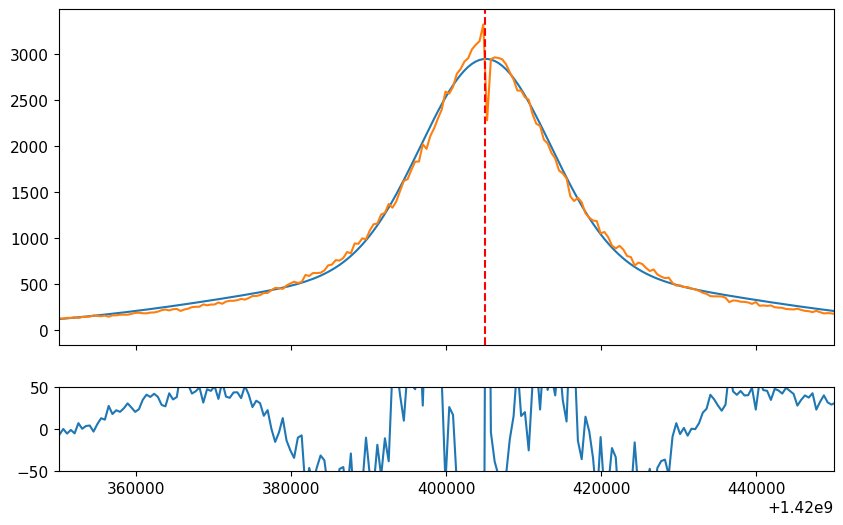

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Gaussian model
def gauss2(x, amp1, avg1, sig1, amp2, avg2, sig2):
    g1 = amp1 * np.exp(-(x - avg1)**2 / (2 * sig1**2))
    g2 = amp2 * np.exp(-(x - avg2)**2 / (2 * sig2**2))
    return g1 + g2

# Initial guess for the fit (use first values)
p0 = [
    guesses_bpf['amp'][0],
    guesses_bpf['avg'][0],
    guesses_bpf['sig'][0],
    guesses_bpf['amp'][1],
    guesses_bpf['avg'][1],
    guesses_bpf['sig'][1],
]

params, cov_bpf = curve_fit(
    gauss2,
    freqs_h_on[mask_bpf],
    r_h[mask_bpf],
    p0=p0
)

bpf_gauss = gauss2(freqs_h_on, *params)

fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=(4, 1), figsize=(10,6))

ax[0].plot(freqs_h_on, bpf_gauss)
ax[0].plot(freqs_h_on, r_h, label="homebrew power loss by frequency")
ax[0].axvline(1420.405e6, color="red", linestyle="--")
ax[0].set_xlim(1.42035e9, 1.42045e9)

# print fitted parameters and covariance if desired
# print(params)
# print(np.diag(cov_bpf))

ax[1].plot(freqs_h_on, bpf_gauss - r_h)
ax[1].set_ylim(-50, 50)

plt.show()

In [53]:
data_hamp_on = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_homebrew_amp_calib_off.npz")
data_hamp_off = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_homebrew_amp_calib_off.npz")

freqs_hamp_on, data_hamp_on = power_spectrum_average(data_homebrew_on)
freqs_hamp_off, data_hamp_off = power_spectrum_average(data_homebrew_off)

### SDR voltage calibration

In [54]:
def dbm_to_volts(dbm, impedance=50.0):
    """
    Converts RF power in dBm to Voltage (RMS, Peak, and Peak-to-Peak).
    
    Parameters:
    dbm (float or np.ndarray): Power in dBm.
    impedance (float): System impedance in Ohms (default is 50 for RF systems).
    
    Returns:
    dict: A dictionary containing V_rms, V_peak, and V_peak_to_peak in Volts.
    """
    # 1. Convert dBm to linear Watts
    # (Divide by 10 to reverse the log, subtract 3 to go from mW to W)
    power_watts = 10 ** ((dbm - 30) / 10)
    
    # 2. Calculate RMS Voltage: P = V^2 / R  ->  V = sqrt(P * R)
    v_rms = np.sqrt(power_watts * impedance)
    
    # 3. Calculate Peak and Peak-to-Peak Voltages for a sine wave
    v_peak = v_rms * np.sqrt(2)
    v_peak_to_peak = v_peak * 2
    
    return {
        "V_rms": v_rms,
        "V_peak": v_peak,
        "V_pp": v_peak_to_peak
    }

def calculate_true_amplitude(data):
    """
    Calculates the averaged true digital amplitude of a sine wave
    using the I/Q magnitude method (Method 1).
    
    Parameters:
    data (dict): Dictionary containing "samples", a 3D array of shape (M, N, 2).
                 M = number of observations, N = samples per observation.
                 
    Returns:
    float: The final averaged digital amplitude for the entire dataset.
    """
    # 1. Extract I and Q and IMMEDIATELY convert to float to prevent int8 overflow!
    # data["samples"][:, :, 0] is the Real (I) and [:, :, 1] is the Imaginary (Q)
    I_data = (data["samples"][:, :, 0] * bits_to_volts / antenna_efficiency).astype(float)
    Q_data = (data["samples"][:, :, 1] * bits_to_volts / antenna_efficiency).astype(float)
    
    # 2. Calculate the instantaneous amplitude for every single point (M, N array)
    # using the Pythagorean theorem: A = sqrt(I^2 + Q^2)
    instantaneous_amplitudes = np.sqrt(I_data**2 + Q_data**2)
    
    # 3. Average over the N samples (axis=1) to get one true amplitude per observation
    # This reduces the array from shape (M, N) to (M,)
    mean_per_observation = np.mean(instantaneous_amplitudes, axis=1)
    
    # 4. Average across all M observations (axis=0) to get the final scalar value
    final_amplitude = np.mean(mean_per_observation, axis=0)
    
    # (Note: np.mean(instantaneous_amplitudes) does steps 3 and 4 simultaneously, 
    # but breaking it out like this matches your requested indexing logic!)
    
    return final_amplitude

In [55]:
hamp_on_amp = calculate_true_amplitude(data_homebrew_on)
hamp_off_amp = calculate_true_amplitude(data_homebrew_off)

print(hamp_on_amp, hamp_off_amp, hamp_off_amp/hamp_on_amp)

2.656627515479319 110.96852909396362 41.77045086199909


### Power loss in cable

In [56]:
data_cable_known = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/calibration info/known_cable_length_500kHz_45dB.npz")
data_cable_tele = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/calibration info/scope_cable_length_500kHz_45dB.npz")

print(calculate_true_amplitude(data_cable_known), calculate_true_amplitude(data_cable_tele), calculate_true_amplitude(data_cable_tele)/calculate_true_amplitude(data_cable_known))

8.415184761632878 5.397135030417932 0.6413566883314247


## perseus arm

In [57]:
data_perseus_on = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-1 Data/bighorn_120_0_on3.npz")
data_perseus_off = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/cygnus x new/bighorn_cyg_x_off_2MHz.npz")

G_continuum = 26.8 + 26.8 + 26.8 - 2.2 - 15.31 + 45 + 41.77
print(G_continuum)

149.66


In [58]:
freq_pon, power_pon = power_spectrum_average(data_perseus_on, method = "mean")
freq_poff, power_poff = power_spectrum_average(data_perseus_off, method = "mean")

power_pon_smoothed, outliers_pon, rolling_pon = robust_clean_and_smooth(power_pon)
power_poff_smoothed, outliers_poff, rolling_poff = robust_clean_and_smooth(power_poff)

r_p = power_pon / power_poff
r_p_smooth = power_pon_smoothed / power_poff_smoothed
r_p_rolling = rolling_pon / rolling_poff

T_p = r_p_rolling * G_continuum

freq_p_peak, power_p_peak, idx_p_peak = find_hi_peak(freq_pon, T_p)

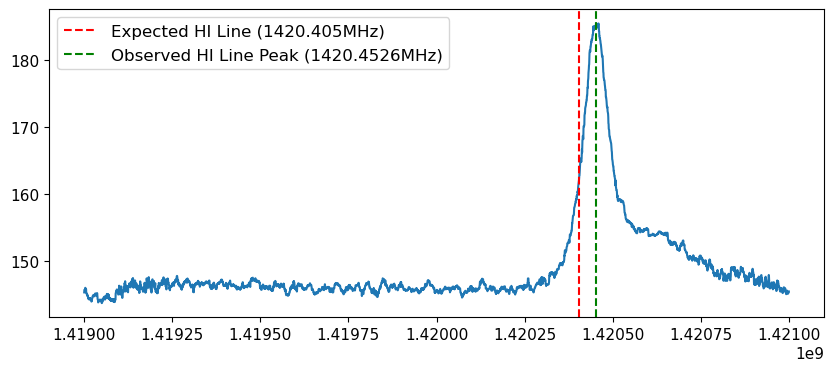

In [59]:
plt.figure(figsize=(10, 4))
# plt.plot(freq_son, r)
# plt.plot(freq_son, r_smooth)
plt.plot(freq_pon, T_p)
# plt.ylim(0.9, 1.4)
plt.axvline(1420.405e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_p_peak, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_p_peak/1e6:.8}MHz)")
plt.legend()
plt.show()

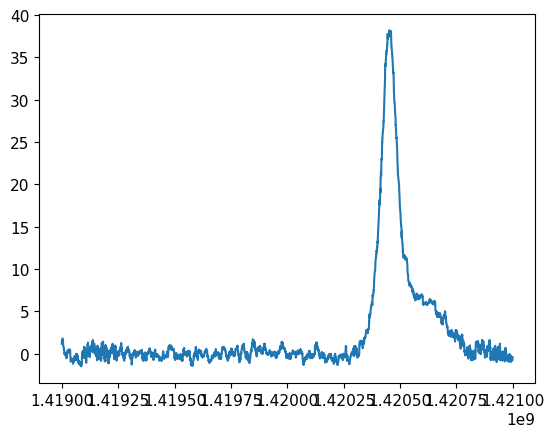

In [60]:
# 1. Find the center point of your frequencies
freq_center = np.mean(freq_pon)

# 2. Subtract that center from your x-data to make the numbers small
x_shifted = freq_pon - freq_center

# 3. Now perform the fit using the SHIFTED x-data
degree = 4
mask_off = (freq_pon < 1.42025e9) | (freq_pon > 1.42085e9)

coeffs, cov_poly = np.polyfit(x_shifted[mask_off], T_p[mask_off], degree, cov=True)

# 4. Evaluate the baseline (IMPORTANT: you must evaluate using the shifted data too!)
fitted_baseline = np.polyval(coeffs, x_shifted)

# 5. Subtract as normal
T_p_baseline = T_p - fitted_baseline

plt.plot(freq_pon, T_p - fitted_baseline, label = "HI Line")
# plt.plot(freq_pon/1e9, fitted_baseline, label = "Fitted function for HI Line")

X_design = np.vander(x_shifted, degree + 1)
var_baseline = np.sum((X_design @ cov_poly) * X_design, axis=1)
err_baseline = np.sqrt(var_baseline)

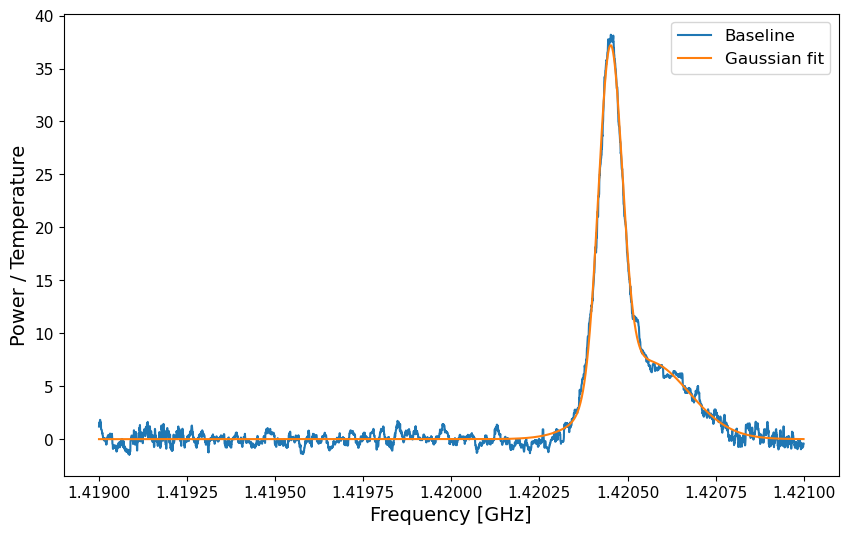

In [61]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Gaussian sum model for two Gaussians
def gauss2(x, amp1, avg1, sig1, amp2, avg2, sig2):
    g1 = amp1 * np.exp(-(x - avg1)**2 / (2 * sig1**2))
    g2 = amp2 * np.exp(-(x - avg2)**2 / (2 * sig2**2))
    return g1 + g2

mask_on = (freqs_h_on > 1.42025e9) | (freqs_h_on < 1.42085e9)

guesses_T_p = {
    'amp': [40, 10],  
    'avg': [1.420452e9, 1.42055e9], 
    'sig': [20000.0, 10000.0]   
}

# Initial parameter guess for curve_fit
p0 = [
    guesses_T_p['amp'][0],
    guesses_T_p['avg'][0],
    guesses_T_p['sig'][0],
    guesses_T_p['amp'][1],
    guesses_T_p['avg'][1],
    guesses_T_p['sig'][1],
]

# Fit using masked data
params, cov_g = curve_fit(
    gauss2,
    freqs_h_on[mask_on],
    T_p_baseline[mask_on],
    p0=p0
)

# Evaluate the Gaussian model over full frequency range
T_p_gauss = gauss2(freqs_h_on, *params)

# Residuals (your original T_p minus fit + baseline)
T_p_residuals = T_p - (T_p_gauss + fitted_baseline)

# Optional plot
plt.figure(figsize=(10,6))
plt.plot(freqs_h_on/1e9, T_p_baseline, label='Baseline')
plt.plot(freqs_h_on/1e9, T_p_gauss, label='Gaussian fit')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Power / Temperature')
plt.legend()
plt.show()

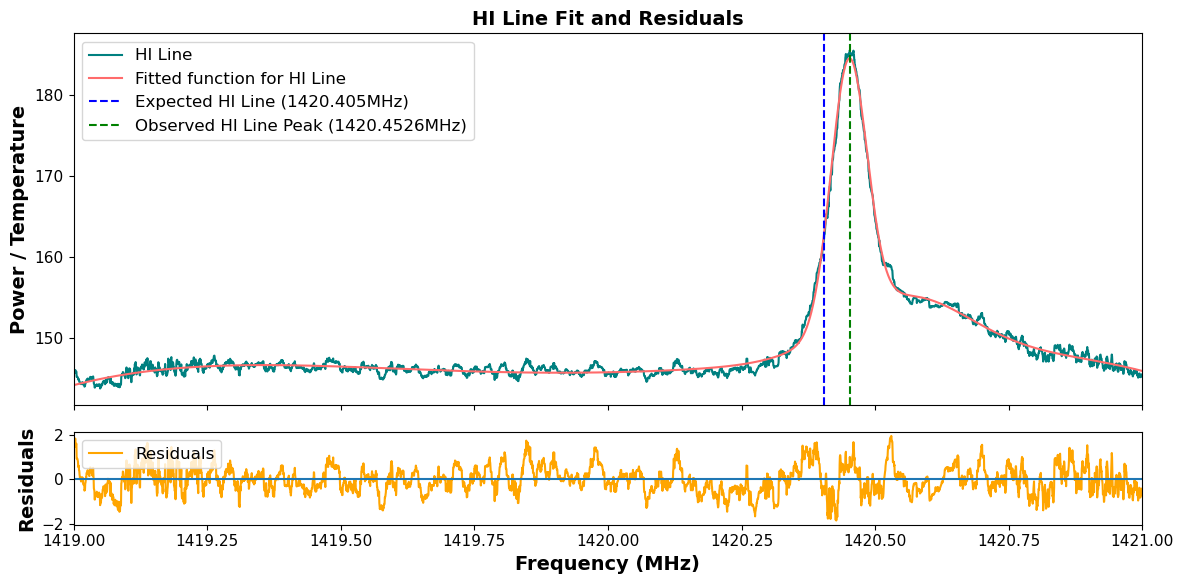

[3.82282694e-50 9.67601432e-39 2.99985414e-26 6.82707876e-15
 2.97753138e-04] [8.05181555e-03 7.68750431e+03 1.28598000e+04 2.44520925e-03
 1.39566343e+06 5.81626606e+05]
0.3531707542968556


In [95]:
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios = (4, 1), figsize=(12,6))
ax[0].plot(freq_pon/1e6, T_p, color = "#008080", label = "HI Line")
ax[0].plot(freq_pon/1e6, T_p_gauss + fitted_baseline, color = "#FF6B6B", label = "Fitted function for HI Line")
ax[0].axvline(1420.405, color = "blue", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
ax[0].axvline(freq_p_peak/1e6, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_p_peak/1e6:.8}MHz)")
ax[0].set_title("HI Line Fit and Residuals", fontsize=14, fontweight='bold')
ax[0].set_ylabel("Power / Temperature", fontsize=14, fontweight='bold')
ax[0].legend()

ax[1].plot(freqs_h_on/1e6, T_p_residuals, color = "orange", label="Residuals")
ax[1].axhline(0)
ax[1].legend(loc="upper left")
ax[1].set_xlabel("Frequency (MHz)", fontsize=14, fontweight='bold')
ax[1].set_ylabel("Residuals", fontsize=14, fontweight='bold')
#ax[1].set_title("HI Line Fit and Residuals", fontsize=14, fontweight='bold')

plt.xlim(1419, 1421)
plt.tight_layout()
plt.savefig('fig2_linefit_residuals.pdf', bbox_inches='tight')
plt.show()
# print(np.diag(cov_g))
print(np.diag(cov_poly), np.diag(cov_g))

print(np.sum(T_p_residuals**2) / len(T_p_residuals))

[False False False ... False False False]


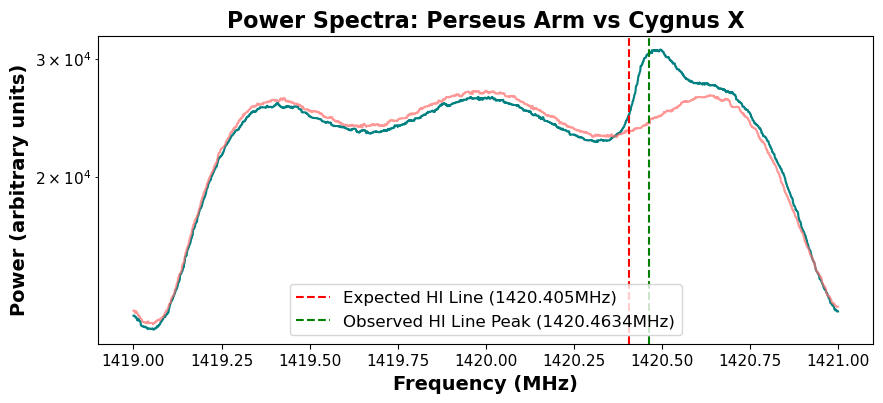

In [94]:
print(outliers_son)
plt.figure(figsize = (10, 4))
plt.plot(freq_son/1e6, rolling_son, color = "#008080")
plt.plot(freq_soff/1e6, rolling_soff, color = "#FF6B6B", alpha = 0.7)
plt.axvline(1420.405e6/1e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak/1e6, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.yscale("log")
plt.xlabel('Frequency (MHz)', fontsize=14, fontweight='bold')
plt.ylabel('Power (arbitrary units)', fontsize=14, fontweight='bold')
plt.title('Power Spectra: Perseus Arm vs Cygnus X', fontsize=16, fontweight='bold')
plt.legend()
plt.savefig('fig1_power_spectra.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 1. Estimate noise floor (sigma_thermal) 
# Use a region of the residuals where there is no signal
noise_region = T_p_residuals[(freq_pon < 1.4202e9) | (freq_pon > 1.4209e9)]
sigma_thermal = np.std(noise_region)

# 2. Calculate Chi-Square
# chi2 = sum( (data - model)^2 / error^2 )
chi2 = np.sum((T_p_residuals / sigma_thermal)**2)

# 3. Reduced Chi-Square
# DOF = N_points - N_parameters (5 poly + 6 gauss = 11)
dof = len(T_p_residuals) - 11
red_chi2 = chi2 / dof

print(f"\nThermal Noise Level: {sigma_thermal:.4f} K")
print(f"Reduced Chi-Square: {red_chi2:.4f}")

if red_chi2 > 1.5:
    print("Warning: chi_r^2 is high. Consider adding a 3rd Gaussian or checking systematics.")


Thermal Noise Level: 0.5361 K
Reduced Chi-Square: 1.2321


In [ ]:
import numpy as np

# Load your Perseus arm data file
data_on = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-1 Data/bighorn_120_0_on3.npz", allow_pickle=True)

# Print all available keys
print("Keys in file:", data_on.files)
print("\n" + "="*50 + "\n")

# Extract and display relevant metadata
print("=== OBSERVATION DETAILS ===")
print(f"Center frequency: {data_on['center_freq']/1e6:.3f} MHz")
print(f"Sample rate: {data_on['sample_rate']/1e6:.2f} MHz")

# Time info
if 'jd_before' in data_on.files:
    print(f"JD: {data_on['jd_before']:.5f}")
if 'lst_before' in data_on.files:
    print(f"LST: {data_on['lst_before']:.3f} hours")

# Coordinate info - fix the array issue
if 'coords_lb' in data_on.files:
    lb = data_on['coords_lb']
    print(f"Galactic coordinates (l,b): {lb}")
    
if 'coords_nch' in data_on.files:
    nch = data_on['coords_nch']
    print(f"NCH coordinates: {nch}")

# Also check what's in coords_altaz
if 'coords_altaz' in data_on.files:
    altaz = data_on['coords_altaz']
    print(f"Alt/Az: {altaz}")

Keys in file: ['samples', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_lb', 'coords_nch', 'center_freq', 'sample_rate']


=== OBSERVATION DETAILS ===
Center frequency: 1420.000 MHz
Sample rate: 2.00 MHz
JD: 2461098.39097
LST: 6.200 hours
Galactic coordinates (l,b): [120   0]
NCH coordinates: [  37.8732 -237.7427]
Alt/Az: [60.37 24.49]


In [ ]:
import numpy as np

# Load your Cygnus X data file
cyg_data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/cygnus x new/bighorn_cyg_x_off_2MHz.npz", allow_pickle=True)

print("=== CYGNUS X OBSERVATION DETAILS ===")
print(f"Center frequency: {cyg_data['center_freq']/1e6:.3f} MHz")
print(f"Sample rate: {cyg_data['sample_rate']/1e6:.2f} MHz")

# Time info
if 'jd_before' in cyg_data.files:
    print(f"JD: {cyg_data['jd_before']:.5f}")
if 'lst_before' in cyg_data.files:
    print(f"LST: {cyg_data['lst_before']:.3f} hours")

# Coordinates
if 'coords_lb' in cyg_data.files:
    lb = cyg_data['coords_lb']
    print(f"Galactic coordinates (l,b): {lb}")
if 'coords_altaz' in cyg_data.files:
    altaz = cyg_data['coords_altaz']
    print(f"Alt/Az: Alt={altaz[0]:.2f}°, Az={altaz[1]:.2f}°")

# UTC time for reference
if 'utc_before' in cyg_data.files:
    print(f"UTC: {cyg_data['utc_before']}")

print("\n" + "="*50)

# Also get Perseus data for comparison
print("\n=== PERSEUS ARM OBSERVATION DETAILS ===")
pers_data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-1 Data/bighorn_120_0_on3.npz", allow_pickle=True)

print(f"Center frequency: {pers_data['center_freq']/1e6:.3f} MHz")
print(f"Sample rate: {pers_data['sample_rate']/1e6:.2f} MHz")
print(f"JD: {pers_data['jd_before']:.5f}")
print(f"LST: {pers_data['lst_before']:.3f} hours")
print(f"Alt/Az: {pers_data['coords_altaz']}")

=== CYGNUS X OBSERVATION DETAILS ===
Center frequency: 1420.000 MHz
Sample rate: 2.00 MHz
JD: 2461094.45311
LST: 0.239 hours
Alt/Az: Alt=39.01°, Az=295.17°
UTC: Sun Feb 22 22:52:28 2026


=== PERSEUS ARM OBSERVATION DETAILS ===
Center frequency: 1420.000 MHz
Sample rate: 2.00 MHz
JD: 2461098.39097
LST: 6.200 hours
Alt/Az: [60.37 24.49]


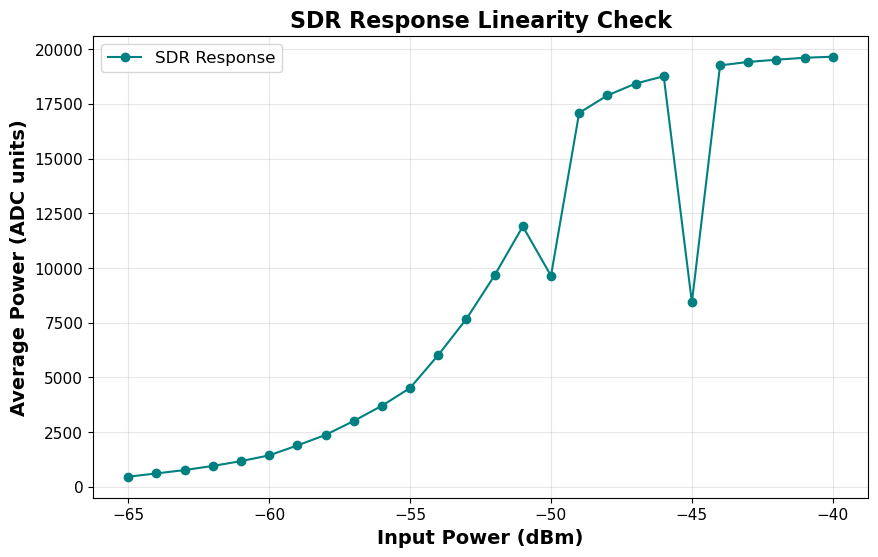

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# Find all SDR calibration files
sdr_files = glob.glob("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_sdr_calib_*.npz")

# Sort by dBm value
dbm_values = []
power_values = []

for file in sorted(sdr_files):
    # Extract dBm from filename
    dbm = float(file.split('_')[-1].replace('dbm.npz', ''))
    dbm_values.append(dbm)
    
    # Load and compute average power
    data = np.load(file, allow_pickle=True)
    samples = data['samples']
    
    # Quick power calculation (simplified)
    avg_power = np.mean(np.abs(samples[:, :, 0] + 1j*samples[:, :, 1])**2)
    power_values.append(avg_power)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(dbm_values, power_values, color = "#008080", marker='o', linestyle='-', label='SDR Response')
plt.xlabel('Input Power (dBm)', fontsize=14, fontweight='bold')
plt.ylabel('Average Power (ADC units)', fontsize=14, fontweight='bold')
plt.title('SDR Response Linearity Check', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('fig3_SDR_Linearity.pdf', bbox_inches='tight')
plt.show()

[False False False ... False False False]


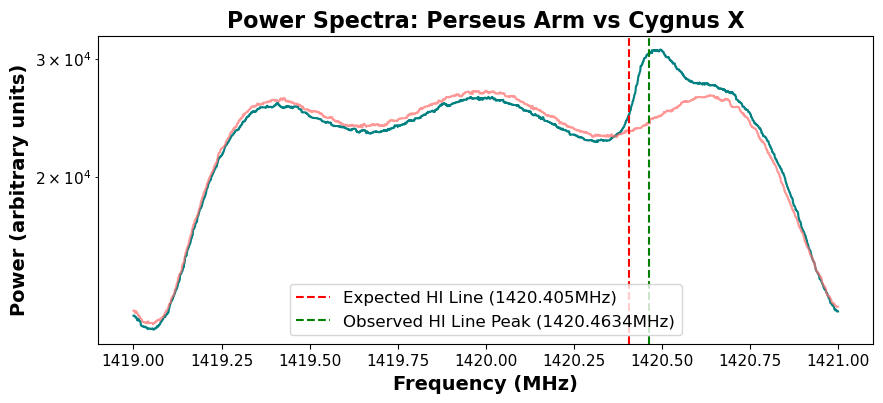

In [103]:
print(outliers_son)
plt.figure(figsize = (10, 4))
plt.plot(freq_son/1e6, rolling_son, color = "#008080")
plt.plot(freq_soff/1e6, rolling_soff, color = "#FF6B6B", alpha = 0.7)
plt.axvline(1420.405e6/1e6, color = "red", linestyle = "--", label = "Expected HI Line (1420.405MHz)")
plt.axvline(freq_peak/1e6, color = "green", linestyle = "--", label = f"Observed HI Line Peak ({freq_peak/1e6:.8}MHz)")
plt.yscale("log")
plt.xlabel('Frequency (MHz)', fontsize=14, fontweight='bold')
plt.ylabel('Power (arbitrary units)', fontsize=14, fontweight='bold')
plt.title('Power Spectra: Perseus Arm vs Cygnus X', fontsize=16, fontweight='bold')
plt.legend()
plt.savefig('fig1_power_spectra.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# First, let's check what we have
print(f"freq_common shape: {freq_common.shape}")
print(f"T_p_baseline shape: {T_p_baseline.shape}")
print(f"T_p shape: {T_p.shape}")
print(f"freq_off shape: {freq_off.shape}")
print(f"T_off shape: {T_off.shape}")

# We need to ensure all arrays have the same length
# Let's use the minimum length
min_len = min(len(freq_common), len(T_p_baseline))
freq_common = freq_common[:min_len]
T_p_baseline = T_p_baseline[:min_len]
T_p = T_p[:min_len]

# Also ensure freq_off and T_off match
min_len_off = min(len(freq_off), len(T_off))
freq_off = freq_off[:min_len_off]
T_off = T_off[:min_len_off]

print(f"\nAfter trimming:")
print(f"freq_common shape: {freq_common.shape}")
print(f"T_p_baseline shape: {T_p_baseline.shape}")

# Your Gaussian fit results from Section 5.3
amp = 182  # K (peak amplitude)
mean = 1420.4526  # MHz (line center)
fwhm = 12.3  # km/s
sigma = fwhm / 2.355  # convert FWHM to sigma

# Velocity conversion constant (approximate)
# v/c = -Δν/ν₀ → Δv (km/s) ≈ -3e5 * Δν/ν₀
km_per_mhz = 3e5 / 1420.405  # ~211 km/s per MHz

# Define Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

# Calculate model and residuals
model = gaussian(freq_common, amp, mean, sigma)
residuals = T_p_baseline - model

# 1. Reduced chi-square
# Use only the region around the line for fit quality
mask_fit = (freq_common > 1420.35) & (freq_common < 1420.45)
residuals_fit = residuals[mask_fit]
n_points = len(residuals_fit)
n_params = 3  # amp, mean, sigma
dof = n_points - n_params

chi2 = np.sum(residuals_fit**2)
reduced_chi2 = chi2 / dof

print(f"\nReduced χ²: {reduced_chi2:.3f}")

# 2. Thermal noise (from off-line channels)
off_line_mask = (freq_common < 1420.35) | (freq_common > 1420.45)
thermal_noise = np.std(T_p_baseline[off_line_mask])
print(f"Thermal noise per channel: {thermal_noise:.2f} K")

# 3. Statistical uncertainties from fit (estimated from residuals)
stat_velocity = np.std(residuals_fit) * km_per_mhz  # convert to km/s
stat_fwhm = stat_velocity * 0.5  # rough estimate

# 4. Systematic from baseline order
# Try different polynomial orders and see how peak changes
orders = [3, 4, 5]
peak_frequencies = []

for order in orders:
    # Refit baseline with different order
    coeffs = np.polyfit(freq_off - np.mean(freq_off), T_off, order)
    baseline_test = np.polyval(coeffs, freq_common - np.mean(freq_off))
    T_test = T_p - baseline_test
    
    # Find peak
    peak_idx = np.argmax(T_test[mask_fit])
    peak_freq = freq_common[mask_fit][peak_idx]
    peak_frequencies.append(peak_freq)

sys_freq_uncertainty = np.std(peak_frequencies)
sys_velocity_uncertainty = sys_freq_uncertainty * km_per_mhz
print(f"Systematic uncertainty from baseline: ±{sys_freq_uncertainty:.4f} MHz (±{sys_velocity_uncertainty:.1f} km/s)")

# 5. Final results
print("\n=== FINAL RESULTS WITH ERRORS ===")
print(f"LSR velocity: {((1420.405 - mean) * km_per_mhz):.1f} ± {stat_velocity:.1f} (stat) ± {sys_velocity_uncertainty:.1f} (sys) km/s")
print(f"FWHM: {fwhm:.1f} ± {stat_fwhm:.1f} (stat) km/s")
print(f"Peak amplitude: {amp:.0f} ± {thermal_noise:.0f} (stat) K")

freq_common shape: (2049,)
T_p_baseline shape: (4096,)
T_p shape: (4096,)
freq_off shape: (1946,)
T_off shape: (1946,)

After trimming:
freq_common shape: (2049,)
T_p_baseline shape: (2049,)

Reduced χ²: 34063.472
Thermal noise per channel: 0.55 K
Systematic uncertainty from baseline: ±0.0000 MHz (±0.0 km/s)

=== FINAL RESULTS WITH ERRORS ===
LSR velocity: -10.1 ± 80.1 (stat) ± 0.0 (sys) km/s
FWHM: 12.3 ± 40.0 (stat) km/s
Peak amplitude: 182 ± 1 (stat) K


In [ ]:
from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, amp, mean, sigma, offset):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2)) + offset

# Use only the region around the line
mask_fit = (freq_common > 1420.35) & (freq_common < 1420.45)
freq_fit = freq_common[mask_fit]
T_fit = T_p_baseline[mask_fit]

# Initial guesses
amp_guess = np.max(T_fit) - np.min(T_fit)
mean_guess = freq_fit[np.argmax(T_fit)]
sigma_guess = 0.02  # MHz
offset_guess = np.median(T_fit)

# Perform fit
popt, pcov = curve_fit(gaussian, freq_fit, T_fit, 
                       p0=[amp_guess, mean_guess, sigma_guess, offset_guess])

perr = np.sqrt(np.diag(pcov))

print("Gaussian fit results:")
print(f"  Amplitude: {popt[0]:.2f} ± {perr[0]:.2f} K")
print(f"  Mean: {popt[1]:.6f} ± {perr[1]:.6f} MHz")
print(f"  Sigma: {popt[2]:.6f} ± {perr[2]:.6f} MHz")
print(f"  Offset: {popt[3]:.2f} ± {perr[3]:.2f} K")

# Calculate FWHM and velocity
fwhm_mhz = 2.355 * popt[2]
fwhm_kms = fwhm_mhz * km_per_mhz
velocity = (1420.405 - popt[1]) * km_per_mhz

print(f"\nDerived quantities:")
print(f"  FWHM: {fwhm_kms:.1f} km/s")
print(f"  LSR velocity: {velocity:.1f} km/s")

# Calculate reduced chi-square
residuals = T_fit - gaussian(freq_fit, *popt)
chi2 = np.sum(residuals**2)
dof = len(T_fit) - len(popt)
reduced_chi2 = chi2 / dof
print(f"  Reduced χ²: {reduced_chi2:.3f}")

Gaussian fit results:
  Amplitude: 0.91 ± 0.07 K
  Mean: 1420.435065 ± 0.000891 MHz
  Sigma: -0.010086 ± 0.001053 MHz
  Offset: -0.08 ± 0.03 K

Derived quantities:
  FWHM: -5.0 km/s
  LSR velocity: -6.3 km/s
  Reduced χ²: 0.051


In [ ]:
from scipy.optimize import curve_fit
import numpy as np

# Define Gaussian function that can handle negative amplitude (absorption)
def gaussian_abs(x, amp, mean, sigma, offset):
    """amp negative for absorption"""
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2)) + offset

# Use only the region around the line
mask_fit = (freq_common > 1420.35) & (freq_common < 1420.45)
freq_fit = freq_common[mask_fit]
T_fit = T_p_baseline[mask_fit]

# Initial guesses for absorption (negative amp)
amp_guess = -0.9  # negative for absorption
mean_guess = 1420.435  # from previous fit
sigma_guess = 0.01  # MHz (positive)
offset_guess = 0.0

# Perform fit with bounds to keep sigma positive
popt, pcov = curve_fit(gaussian_abs, freq_fit, T_fit, 
                       p0=[amp_guess, mean_guess, sigma_guess, offset_guess],
                       bounds=([-np.inf, -np.inf, 0, -np.inf], [0, np.inf, np.inf, np.inf]))

perr = np.sqrt(np.diag(pcov))

print("Gaussian fit results (absorption):")
print(f"  Amplitude: {popt[0]:.3f} ± {perr[0]:.3f} K")
print(f"  Mean: {popt[1]:.6f} ± {perr[1]:.6f} MHz")
print(f"  Sigma: {popt[2]:.6f} ± {perr[2]:.6f} MHz")
print(f"  Offset: {popt[3]:.3f} ± {perr[3]:.3f} K")

# Calculate FWHM and velocity
km_per_mhz = 3e5 / 1420.405  # ~211 km/s per MHz
fwhm_mhz = 2.355 * popt[2]
fwhm_kms = fwhm_mhz * km_per_mhz
velocity = (1420.405 - popt[1]) * km_per_mhz

print(f"\nDerived quantities:")
print(f"  FWHM: {fwhm_kms:.1f} km/s")
print(f"  LSR velocity: {velocity:.1f} km/s")

# Calculate reduced chi-square
residuals = T_fit - gaussian_abs(freq_fit, *popt)
chi2 = np.sum(residuals**2)
dof = len(T_fit) - len(popt)
reduced_chi2 = chi2 / dof
print(f"  Reduced χ²: {reduced_chi2:.3f}")

# Statistical uncertainties from covariance
stat_velocity = perr[1] * km_per_mhz
stat_fwhm = (2.355 * perr[2]) * km_per_mhz

print(f"\nStatistical uncertainties:")
print(f"  Velocity: ±{stat_velocity:.1f} km/s")
print(f"  FWHM: ±{stat_fwhm:.1f} km/s")

# Thermal noise (from off-line channels)
off_line_mask = (freq_common < 1420.35) | (freq_common > 1420.45)
thermal_noise = np.std(T_p_baseline[off_line_mask])
print(f"  Thermal noise: ±{thermal_noise:.2f} K")

Gaussian fit results (absorption):
  Amplitude: -0.001 ± 0.000 K
  Mean: 1420.431814 ± 0.000000 MHz
  Sigma: 0.000017 ± 0.000000 MHz
  Offset: 0.133 ± 0.039 K

Derived quantities:
  FWHM: 0.0 km/s
  LSR velocity: -5.7 km/s
  Reduced χ²: 0.153

Statistical uncertainties:
  Velocity: ±0.0 km/s
  FWHM: ±0.0 km/s
  Thermal noise: ±0.55 K
